
🏁 Race Strategy Optimizer — che tipo di AI è?

🔹 Versione 1 — ML classico (più realistico all’inizio)
Usi modelli supervisionati per stimare:

degrado gomme → Regressione (XGBoost / RF)
probabilità Safety Car → classificazione / survival analysis
tempo pit stop → regressione
perdita tempo in traffico → regressione
Poi fai:

Simulazione Monte Carlo
Ricerca combinatoria sulle strategie
👉 Qui sei nel mondo ML + simulazione.
È molto ingegneristico e realistico (molto vicino a come lavorano davvero i team).


🔹 Versione 2 — Deep Learning
Se vuoi usare NN:

LSTM per degrado gomme dipendente dalla sequenza
Transformer per modellare andamento gara
Reti neurali per stimare interazioni traffico
Qui sei in Deep Learning su serie temporali.


🔹 Versione 3 — Reinforcement Learning (livello alto)

Qui fai:

Ambiente = simulatore gara
Agente = strategist
Azioni = pit, cambio gomma
Reward = posizione finale o tempo gara
Questo è RL puro.

Ed è il progetto più potente da portfolio.


questa era una piccola roadmap, dimmi che ne pensi poi ti do altre specifiche

<div style="padding: 10px; background-color: #ffeb3b; color: black; border-left: 5px solid #f44336;">
  <b>⚠️ CELLA DI INIZIALIZZAZIONE: Eseguire prima di continuare</b>
</div>

In [2]:
import fastf1 as ff1
import pandas as pd
import numpy as np

# Abilitiamo la cache che hai già popolato
ff1.Cache.enable_cache('./cache')
# ff1.set_log_level('ERROR')
ff1.Cache.offline_mode(True)

In [11]:
s1 = ff1.get_session(2024, 'monza', 'R')
s1.load(telemetry=False, weather=True)

core           INFO 	Loading data for Italian Grand Prix - Race [v3.6.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['16', '81', '4', '55', '44', '1', '63', '11', '23', '20', '14', '43', '3', '31', '10', '77', '27', '24', '18', '22']


In [16]:
driver = 'VER'
# fastest lap of the driver
fastest_lap = s1.laps.pick_drivers(driver).pick_fastest()

In [12]:
schedule = ff1.get_event_schedule(2022)

In [13]:
schedule

,RoundNumber,Country,Location,OfficialEventName,EventDate,EventName,EventFormat,Session1,Session1Date,Session1DateUtc,...,Session3,Session3Date,Session3DateUtc,Session4,Session4Date,Session4DateUtc,Session5,Session5Date,Session5DateUtc,F1ApiSupport
0,0,Spain,Spain,FORMULA 1 PRE-SEASON TRACK SESSION 2022,2022-02-25,Pre-Season Track Session,testing,Practice 1,2022-02-23 09:00:00+01:00,2022-02-23 08:00:00,...,Practice 3,2022-02-25 09:00:00+01:00,2022-02-25 08:00:00,None,NaT,NaT,None,NaT,NaT,False
1,0,Bahrain,Bahrain,FORMULA 1 ARAMCO PRE-SEASON TESTING 2022,2022-03-12,Pre-Season Test,testing,Practice 1,2022-03-10 10:00:00+03:00,2022-03-10 07:00:00,...,Practice 3,2022-03-12 10:00:00+03:00,2022-03-12 07:00:00,None,NaT,NaT,None,NaT,NaT,True
2,1,Bahrain,Sakhir,FORMULA 1 GULF AIR BAHRAIN GRAND PRIX 2022,2022-03-20,Bahrain Grand Prix,conventional,Practice 1,2022-03-18 15:00:00+03:00,2022-03-18 12:00:00,...,Practice 3,2022-03-19 15:00:00+03:00,2022-03-19 12:00:00,Qualifying,2022-03-19 18:00:00+03:00,2022-03-19 15:00:00,Race,2022-03-20 18:00:00+03:00,2022-03-20 15:00:00,True
3,2,Saudi Arabia,Jeddah,FORMULA 1 STC SAUDI ARABIAN GRAND PRIX 2022,2022-03-27,Saudi Arabian Grand Prix,conventional,Practice 1,2022-03-25 17:00:00+03:00,2022-03-25 14:00:00,...,Practice 3,2022-03-26 17:00:00+03:00,2022-03-26 14:00:00,Qualifying,2022-03-26 20:00:00+03:00,2022-03-26 17:00:00,Race,2022-03-27 20:00:00+03:00,2022-03-27 17:00:00,True
4,3,Australia,Melbourne,FORMULA 1 HEINEKEN AUSTRALIAN GRAND PRIX 2022,2022-04-10,Australian Grand Prix,conventional,Practice 1,2022-04-08 13:00:00+10:00,2022-04-08 03:00:00,...,Practice 3,2022-04-09 13:00:00+10:00,2022-04-09 03:00:00,Qualifying,2022-04-09 16:00:00+10:00,2022-04-09 06:00:00,Race,2022-04-10 15:00:00+10:00,2022-04-10 05:00:00,True
5,4,Italy,Imola,FORMULA 1 ROLEX GRAN PREMIO DEL MADE IN ITALY ...,2022-04-24,Emilia Romagna Grand Prix,sprint,Practice 1,2022-04-22 13:30:00+02:00,2022-04-22 11:30:00,...,Practice 2,2022-04-23 12:30:00+02:00,2022-04-23 10:30:00,Sprint,2022-04-23 16:30:00+02:00,2022-04-23 14:30:00,Race,2022-04-24 15:00:00+02:00,2022-04-24 13:00:00,True
6,5,United States,Miami,FORMULA 1 CRYPTO.COM MIAMI GRAND PRIX 2022,2022-05-08,Miami Grand Prix,conventional,Practice 1,2022-05-06 14:30:00-04:00,2022-05-06 18:30:00,...,Practice 3,2022-05-07 13:00:00-04:00,2022-05-07 17:00:00,Qualifying,2022-05-07 16:00:00-04:00,2022-05-07 20:00:00,Race,2022-05-08 15:30:00-04:00,2022-05-08 19:30:00,True
7,6,Spain,Barcelona,FORMULA 1 PIRELLI GRAN PREMIO DE ESPAÑA 2022,2022-05-22,Spanish Grand Prix,conventional,Practice 1,2022-05-20 14:00:00+02:00,2022-05-20 12:00:00,...,Practice 3,2022-05-21 13:00:00+02:00,2022-05-21 11:00:00,Qualifying,2022-05-21 16:00:00+02:00,2022-05-21 14:00:00,Race,2022-05-22 15:00:00+02:00,2022-05-22 13:00:00,True
8,7,Monaco,Monaco,FORMULA 1 GRAND PRIX DE MONACO 2022,2022-05-29,Monaco Grand Prix,conventional,Practice 1,2022-05-27 14:00:00+02:00,2022-05-27 12:00:00,...,Practice 3,2022-05-28 13:00:00+02:00,2022-05-28 11:00:00,Qualifying,2022-05-28 16:00:00+02:00,2022-05-28 14:00:00,Race,2022-05-29 15:00:00+02:00,2022-05-29 13:00:00,True
9,8,Azerbaijan,Baku,FORMULA 1 AZERBAIJAN GRAND PRIX 2022,2022-06-12,Azerbaijan Grand Prix,conventional,Practice 1,2022-06-10 15:00:00+04:00,2022-06-10 11:00:00,...,Practice 3,2022-06-11 15:00:00+04:00,2022-06-11 11:00:00,Qualifying,2022-06-11 18:00:00+04:00,2022-06-11 14:00:00,Race,2022-06-12 15:00:00+04:00,2022-06-12 11:00:00,True


In [18]:
fastest_lap

Time                  0 days 01:57:20.598000
Driver                                   VER
DriverNumber                               1
LapTime               0 days 00:01:21.745000
LapNumber                               43.0
Stint                                    3.0
PitOutTime                               NaT
PitInTime                                NaT
Sector1Time           0 days 00:00:26.877000
Sector2Time           0 days 00:00:27.614000
Sector3Time           0 days 00:00:27.254000
Sector1SessionTime    0 days 01:56:25.747000
Sector2SessionTime    0 days 01:56:53.361000
Sector3SessionTime    0 days 01:57:20.615000
SpeedI1                                318.0
SpeedI2                                322.0
SpeedFL                                303.0
SpeedST                                330.0
IsPersonalBest                          True
Compound                              MEDIUM
TyreLife                                 2.0
FreshTyre                               True
Team      

In [27]:
def extract_race_data(years):
    all_data = []
    
    for year in years:
        schedule = ff1.get_event_schedule(year)
        # Filter for completed races only
        for _, event in schedule.iterrows():
            if event['EventFormat'] == 'conventional': # Focus on standard race weekends
                try:
                    session = ff1.get_session(year, event['EventName'], 'R')
                    session.load(telemetry=False, weather=True)
                    
                    # 1Get clean laps (no pits, no out-laps)
                    laps = session.laps.pick_accurate().copy()
                    
                    # 2. Basic Feature Engineering per lap
                    # Adding metadata for later filtering
                    laps['Year'] = year
                    laps['GP'] = event['EventName']
                    laps['TrackTemp'] = session.weather_data['TrackTemp'].mean()
                    
                    # Calculate relative fuel load (simple linear approximation)
                    max_laps = session.laps['LapNumber'].max()
                    laps['FuelLoad'] = 100 * (1 - (laps['LapNumber'] / max_laps))
                    
                    # Convert LapTime to seconds
                    laps['LapTimeSeconds'] = laps['LapTime'].dt.total_seconds()
                    
                    all_data.append(laps)
                    print(f"Loaded: {year} {event['EventName']}")
                    
                except Exception as e:
                    print(f"Skipping {event['EventName']}: {e}")

    return pd.concat(all_data, ignore_index=True)

In [ ]:
def get_processed_data(years):
    all_laps_list = []
    
    for year in years:
        print(f"\n--- Processing Season: {year} ---")
        schedule = ff1.get_event_schedule(year)
        
        # We only want standard GP events (no testing)
        events = schedule[schedule['EventFormat'] == 'conventional']
        
        for _, event in events.iterrows():
            gp_name = event['EventName']
            try:
                # Load session - offline mode is implicit if files are in cache
                session = ff1.get_session(year, gp_name, 'R')
                session.load(telemetry=False, weather=True)
                
                # 1. Selection: Accurate laps only
                laps = session.laps.pick_accurate().copy()
                
                # Add basic metadata
                laps['Year'] = year
                laps['GP'] = gp_name
                
                # 2. Weather Data
                # Get average track temperature for the race
                if not session.weather_data.empty:
                    laps['TrackTemp'] = session.weather_data['TrackTemp'].mean()
                else:
                    laps['TrackTemp'] = np.nan

                # 3. Fuel Simulation (Basic linear model)
                # Starting with ~100kg and burning ~1.6kg per lap (average)
                max_laps = session.laps['LapNumber'].max()
                laps['FuelLoad'] = 100 * (1 - (laps['LapNumber'] / max_laps))

                # 4. Lap Time conversion to seconds
                laps['LapTimeSeconds'] = laps['LapTime'].dt.total_seconds()

                # 5. Feature Engineering: Tyre Age & Compound
                # Calculate age of the tire set for each driver in this specific race
                laps['TyreAge'] = laps.groupby(['Driver', 'Stint']).cumcount() + 1
                
                compound_map = {'SOFT': 1, 'MEDIUM': 2, 'HARD': 3}
                laps['CompoundNumeric'] = laps['Compound'].map(compound_map)

                # 6. Feature Engineering: Traffic (Gap to car in front)
                # Sorting by Time (crossing the line) to calculate gaps
                laps = laps.sort_values(by='Time')
                laps['GapToFront'] = laps['Time'].diff().dt.total_seconds()
                # If gap is > 10s or negative (due to pit), we assume clean air or lap 1
                laps.loc[(laps['GapToFront'] > 10) | (laps['GapToFront'] < 0), 'GapToFront'] = 10
                laps['InTraffic'] = (laps['GapToFront'] < 1.5).astype(int)

                # 7. Feature Engineering: Track Evolution
                # Normalizing lap times against the race average at that specific lap
                avg_lap_time = laps.groupby('LapNumber')['LapTimeSeconds'].transform('mean')
                laps['TrackEvolution'] = avg_lap_time / avg_lap_time.iloc[0]

                all_laps_list.append(laps)
                print(f"Successfully processed: {gp_name}")

            except Exception as e:
                print(f"Skipping {gp_name}: {e}")

    # Concatenate all sessions
    full_df = pd.concat(all_laps_list, ignore_index=True)
    
    return full_df

In [34]:
import os

# --- Execution ---
years_range = [2022, 2023, 2024, 2025]  # reuse existing notebook variable
final_df = get_processed_data(years_range)

# Save to CSV
data_dir = './f1_data'
os.makedirs(data_dir, exist_ok=True)

output_file = os.path.join(data_dir, 'f1_strategy_dataset_22_25.csv')
final_df.to_csv(output_file, index=False)
print(f"\n✅ Dataset saved to {output_file} | Total rows: {len(final_df)}")


--- Processing Season: 2022 ---
Successfully processed: Bahrain Grand Prix
Successfully processed: Saudi Arabian Grand Prix
Successfully processed: Australian Grand Prix
Successfully processed: Miami Grand Prix
Successfully processed: Spanish Grand Prix
Successfully processed: Monaco Grand Prix
Successfully processed: Azerbaijan Grand Prix
Successfully processed: Canadian Grand Prix
Successfully processed: British Grand Prix
Successfully processed: French Grand Prix
Successfully processed: Hungarian Grand Prix
Successfully processed: Belgian Grand Prix
Successfully processed: Dutch Grand Prix
Successfully processed: Italian Grand Prix
Successfully processed: Singapore Grand Prix
Successfully processed: Japanese Grand Prix
Successfully processed: United States Grand Prix
Successfully processed: Mexico City Grand Prix
Successfully processed: Abu Dhabi Grand Prix

--- Processing Season: 2023 ---
Successfully processed: Bahrain Grand Prix
Successfully processed: Saudi Arabian Grand Prix
S

_____________

In [1]:
import pandas as pd
import numpy as np
import os

In [2]:
data_dir = './f1_data'
output_file = os.path.join(data_dir, 'f1_strategy_dataset_22_25.csv')

data = pd.read_csv(output_file)

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67803 entries, 0 to 67802
Data columns (total 41 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Time                67803 non-null  object 
 1   Driver              67803 non-null  object 
 2   DriverNumber        67803 non-null  int64  
 3   LapTime             67803 non-null  object 
 4   LapNumber           67803 non-null  float64
 5   Stint               67803 non-null  float64
 6   PitOutTime          0 non-null      float64
 7   PitInTime           0 non-null      float64
 8   Sector1Time         67803 non-null  object 
 9   Sector2Time         67803 non-null  object 
 10  Sector3Time         67803 non-null  object 
 11  Sector1SessionTime  67644 non-null  object 
 12  Sector2SessionTime  67803 non-null  object 
 13  Sector3SessionTime  67803 non-null  object 
 14  SpeedI1             56141 non-null  float64
 15  SpeedI2             67021 non-null  float64
 16  Spee

In [8]:
features_to_keep = [
    'Year', 'GP', 'Driver', 'Team', 'Compound', 'TyreLife', 'FreshTyre', 
    'Stint', 'LapNumber', 'FuelLoad', 'TrackTemp', 'TrackEvolution', 
    'InTraffic', 'LapTimeSeconds', 'TrackStatus'
]

def clean_f1_data_ml(df):
    df_clean = df[features_to_keep].copy()

    # Keep only green flags laps
    df_clean = df_clean[df_clean['TrackStatus'] == 1]

    # Only dry compound
    df_clean = df_clean[df_clean['Compound'].isin(['SOFT', 'MEDIUM', 'HARD'])]
    
    # Driver-specific Outlier Removal
    def remove_driver_outliers(group):
        # Using a 7% threshold over the median lap time for that specific driver/stint
        # This removes mistakes, pit entries not caught by FastF1, or yellow flag sectors
        driver_median = group['LapTimeSeconds'].median()
        return group[group['LapTimeSeconds'] < (driver_median * 1.07)]

    # Apply the filtering logic
    df_clean = df_clean.groupby(
        ['Year', 'GP', 'Driver', 'Compound'], 
        group_keys=False
    ).apply(remove_driver_outliers, include_groups=True).reset_index()

    # Fixing names
    # Team names mapping to unify technical cycles
    df_clean['Team'] = df_clean['Team'].replace(['AlphaTauri', 'Racing Bulls'], 'RB')
    df_clean['Team'] = df_clean['Team'].replace(['Alfa Romeo'], 'Kick Sauber')
   
    df_clean['FuelLoad'] = df_clean["FuelLoad"].apply(lambda x: x + 1)

    return df_clean.reset_index(drop=True)

df_ready_for_ml = clean_f1_data_ml(data)
print(f"Data cleaning complete. Remaining samples: {len(df_ready_for_ml)}")

Data cleaning complete. Remaining samples: 62291


C:\Users\lucam\AppData\Local\Temp\ipykernel_26816\2623874866.py:27: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(remove_driver_outliers, include_groups=True).reset_index()


In [9]:
df_compounds = pd.read_csv('./f1_data/f1_unique_circuits_complete.csv')
df_compounds[['Country', 'Location', 'EventName', 'Soft', 'Medium', 'Hard']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Country    24 non-null     object
 1   Location   24 non-null     object
 2   EventName  24 non-null     object
 3   Soft       24 non-null     object
 4   Medium     24 non-null     object
 5   Hard       24 non-null     object
dtypes: object(6)
memory usage: 1.3+ KB


In [10]:
import pandas as pd
import numpy as np

def apply_compound_mapping(main_df, compounds_df):
    """
    Joins the compound CSV with the main dataframe.
    Fills missing GP data with default values C2, C3, C4.
    """
    # 1. Merge the dataframes on GP name
    # We assume 'EventName' in compounds_df matches 'GP' in main_df
    df_merged = pd.merge(
        main_df, 
        compounds_df[['EventName', 'Soft', 'Medium', 'Hard']], 
        left_on='GP', 
        right_on='EventName', 
        how='left'
    )

    # 2. Fill missing values for GPs not in the compound CSV (like France 2022)
    # Defaulting to the central range: Soft=C4, Medium=C3, Hard=C2
    df_merged['Soft'] = df_merged['Soft'].fillna('C4')
    df_merged['Medium'] = df_merged['Medium'].fillna('C3')
    df_merged['Hard'] = df_merged['Hard'].fillna('C2')

    # 3. Create a single 'SpecificCompound' column based on the current lap
    def get_specific_c(row):
        compound = str(row['Compound']).upper()
        if 'SOFT' in compound:
            return row['Soft']
        elif 'MEDIUM' in compound:
            return row['Medium']
        elif 'HARD' in compound:
            return row['Hard']
        else:
            return np.nan # For Intermediates or Wets if present

    df_merged['SpecificCompound'] = df_merged.apply(get_specific_c, axis=1)

    # Clean up: remove the helper columns from the merge
    df_merged = df_merged.drop(columns=['EventName', 'Soft', 'Medium', 'Hard'])
    
    return df_merged

# Execution
df_final = apply_compound_mapping(df_ready_for_ml, df_compounds)

In [12]:
def check_dataset_integrity(df):
    """
    Checks for missing values and provides a summary of the dataset health.
    """
    print("--- Dataset Integrity Check ---")
    
    # 1. Count nulls per column
    null_counts = df.isnull().sum()
    null_percentages = (null_counts / len(df)) * 100
    
    # 2. Filter only columns with nulls
    missing_data = pd.concat([null_counts, null_percentages], axis=1, keys=['Total Nulls', 'Percentage'])
    missing_data = missing_data[missing_data['Total Nulls'] > 0]
    
    if missing_data.empty:
        print("✅ No missing values found! The dataset is clean.")
    else:
        print("⚠️ Missing values detected:")
        print(missing_data)
        
    # 3. Check for 'SpecificCompound' validity
    # We want to make sure we don't have 'nan' strings or empty values here
    unique_compounds = df['SpecificCompound'].unique()
    print(f"\nDetected Compounds: {unique_compounds}")
    
    return missing_data

# Run the check
missing_report = check_dataset_integrity(df_final)

--- Dataset Integrity Check ---
⚠️ Missing values detected:
          Total Nulls  Percentage
TyreLife           58    0.093111

Detected Compounds: ['C3' 'C4' 'C5' 'C6' 'C2' 'C1']


In [13]:
# 1. Drop rows where TyreLife is NaN
df_final = df_final.dropna(subset=['TyreLife'])

# 2. Reset index to ensure it's continuous after drops
df_final = df_final.reset_index(drop=True)

print(f"Final clean dataset size: {len(df_final)} rows")

Final clean dataset size: 62233 rows


In [14]:
from sklearn.preprocessing import LabelEncoder

def apply_final_encoding(df):
    """
    Transforms categorical strings into numerical values for ML.
    """
    # 1. Ordinal Mapping for Compounds (Physical hierarchy)
    compound_map = {
        'C1': 1, 'C2': 2, 'C3': 3, 'C4': 4, 'C5': 5, 'C6': 6
    }
    df['SpecificCompound_Encoded'] = df['SpecificCompound'].map(compound_map)

    # 2. Label Encoding for Team
    team_le = LabelEncoder()
    df['Team_Encoded'] = team_le.fit_transform(df['Team'])
    
    # 3. Label Encoding for Driver
    driver_le = LabelEncoder()
    df['Driver_Encoded'] = driver_le.fit_transform(df['Driver'])
    
    # 4. Label Encoding for GP (Crucial for track characteristics!)
    gp_le = LabelEncoder()
    df['GP_Encoded'] = gp_le.fit_transform(df['GP'])

    # 5. Binary Encoding for FreshTyre (Boolean to 0/1)
    df['FreshTyre'] = df['FreshTyre'].astype(int)

    # Store encoders if we need to inverse_transform later
    return df, team_le, driver_le, gp_le

# Execution
df_encoded, team_encoder, driver_encoder, gp_encoder = apply_final_encoding(df_final)

# Display the mapping for verification
print("Team Mapping:", dict(zip(team_encoder.classes_, team_encoder.transform(team_encoder.classes_))))
print("Driver Mapping:", dict(zip(driver_encoder.classes_, driver_encoder.transform(driver_encoder.classes_)))) 
print("GP Mapping:", dict(zip(gp_encoder.classes_, gp_encoder.transform(gp_encoder.classes_))))
print(f"SpecificCompound unique values: {df_encoded['SpecificCompound_Encoded'].unique()}")

Team Mapping: {'Alpine': np.int64(0), 'Aston Martin': np.int64(1), 'Ferrari': np.int64(2), 'Haas F1 Team': np.int64(3), 'Kick Sauber': np.int64(4), 'McLaren': np.int64(5), 'Mercedes': np.int64(6), 'RB': np.int64(7), 'Red Bull Racing': np.int64(8), 'Williams': np.int64(9)}
Driver Mapping: {'ALB': np.int64(0), 'ALO': np.int64(1), 'ANT': np.int64(2), 'BEA': np.int64(3), 'BOR': np.int64(4), 'BOT': np.int64(5), 'COL': np.int64(6), 'DEV': np.int64(7), 'DOO': np.int64(8), 'GAS': np.int64(9), 'HAD': np.int64(10), 'HAM': np.int64(11), 'HUL': np.int64(12), 'LAT': np.int64(13), 'LAW': np.int64(14), 'LEC': np.int64(15), 'MAG': np.int64(16), 'MSC': np.int64(17), 'NOR': np.int64(18), 'OCO': np.int64(19), 'PER': np.int64(20), 'PIA': np.int64(21), 'RIC': np.int64(22), 'RUS': np.int64(23), 'SAI': np.int64(24), 'SAR': np.int64(25), 'STR': np.int64(26), 'TSU': np.int64(27), 'VER': np.int64(28), 'VET': np.int64(29), 'ZHO': np.int64(30)}
GP Mapping: {'Abu Dhabi Grand Prix': np.int64(0), 'Australian Grand P

________

In [18]:
# Create LapDeltaSeconds: Difference between each lap and the fastest lap of that GP
# This normalizes performance across different tracks
best_laps = df_encoded.groupby(['Year', 'GP'])['LapTimeSeconds'].transform('min')
df_encoded['LapDeltaSeconds'] = df_encoded['LapTimeSeconds'] - best_laps

print("Column 'LapDeltaSeconds' created successfully.")

Column 'LapDeltaSeconds' created successfully.


In [19]:
data_dir = './f1_data'
os.makedirs(data_dir, exist_ok=True)

output_file = os.path.join(data_dir, 'f1_dataset_encoded_22_25.csv')
df_encoded.to_csv(output_file, index=False)
print(f"\n✅ Dataset saved to {output_file} | Total rows: {len(df_encoded)}")


✅ Dataset saved to ./f1_data\f1_dataset_encoded_22_25.csv | Total rows: 62233


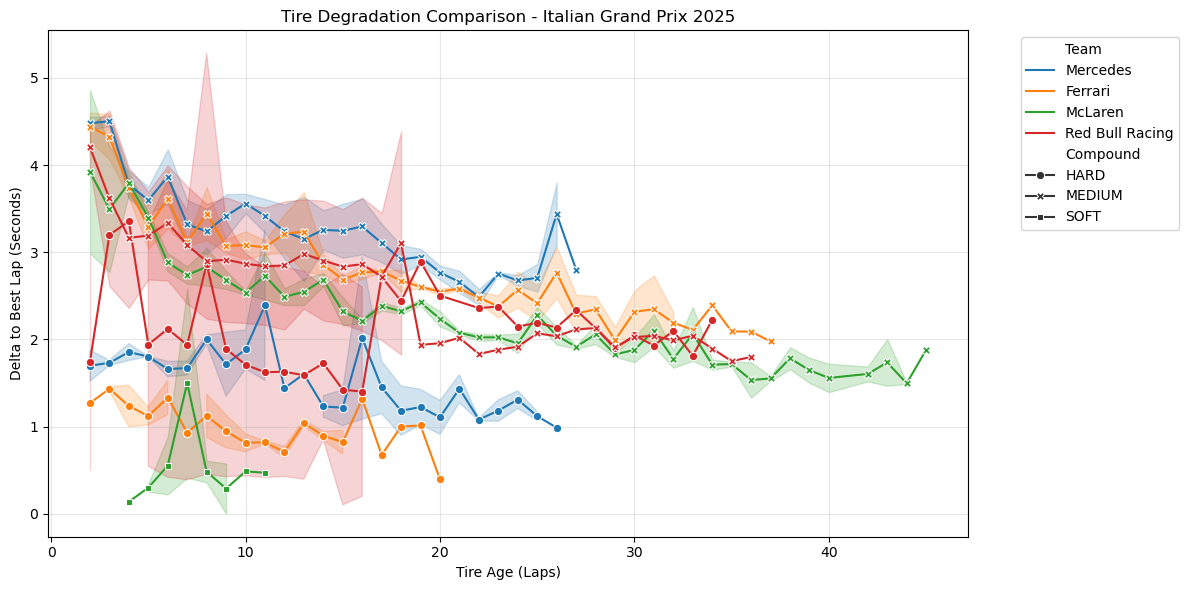

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_degradation_trend(df, gp_name, year):
    # Filter for a specific race
    # Note: using 'str.contains' for GP to handle 'Italian Grand Prix' vs 'Monza'
    race_data = df[(df['GP'].str.contains(gp_name)) & (df['Year'] == year)].copy()
    
    if race_data.empty:
        print(f"No data found for {gp_name} {year}")
        return

    plt.figure(figsize=(12, 6))
    
    # Filter for main teams
    top_teams = ['Red Bull Racing', 'Ferrari', 'Mercedes', 'McLaren']
    filtered_teams = race_data[race_data['Team'].isin(top_teams)]
    
    sns.lineplot(
        data=filtered_teams, 
        x='TyreLife', 
        y='LapDeltaSeconds', 
        hue='Team', 
        style='Compound',
        markers=True, 
        dashes=False
    )
    
    plt.title(f"Tire Degradation Comparison - {gp_name} {year}")
    plt.xlabel("Tire Age (Laps)")
    plt.ylabel("Delta to Best Lap (Seconds)")
    plt.grid(True, alpha=0.3)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Run the plot
plot_degradation_trend(df_encoded, 'Italian Grand Prix', 2025)

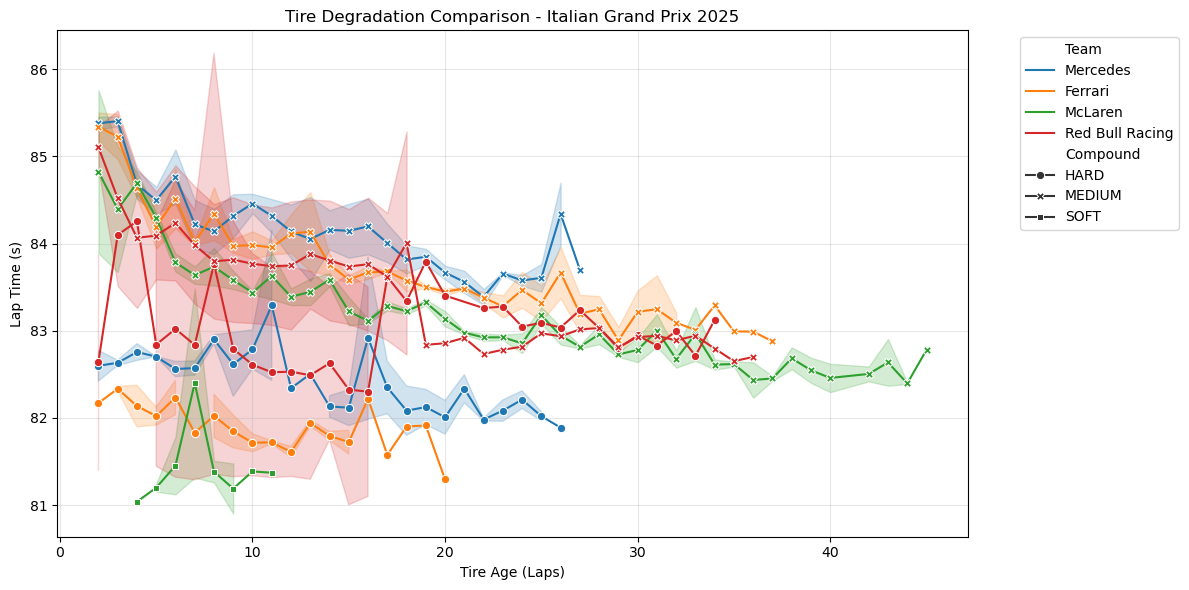

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_degradation_trend(df, gp_name, year):
    # Filter for a specific race
    # Note: using 'str.contains' for GP to handle 'Italian Grand Prix' vs 'Monza'
    race_data = df[(df['GP'].str.contains(gp_name)) & (df['Year'] == year)].copy()
    
    if race_data.empty:
        print(f"No data found for {gp_name} {year}")
        return

    plt.figure(figsize=(12, 6))
    
    # Filter for main teams
    top_teams = ['Red Bull Racing', 'Ferrari', 'Mercedes', 'McLaren']
    filtered_teams = race_data[race_data['Team'].isin(top_teams)]
    
    sns.lineplot(
        data=filtered_teams, 
        x='TyreLife', 
        y='LapTimeSeconds', 
        hue='Team', 
        style='Compound',
        markers=True, 
        dashes=False
    )
    
    plt.title(f"Tire Degradation Comparison - {gp_name} {year}")
    plt.xlabel("Tire Age (Laps)")
    plt.ylabel("Lap Time (s)")
    plt.grid(True, alpha=0.3)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Run the plot
plot_degradation_trend(df_encoded, 'Italian Grand Prix', 2025)

In [65]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62233 entries, 0 to 62232
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   index                     62233 non-null  int64  
 1   Year                      62233 non-null  int64  
 2   GP                        62233 non-null  object 
 3   Driver                    62233 non-null  object 
 4   Team                      62233 non-null  object 
 5   Compound                  62233 non-null  object 
 6   TyreLife                  62233 non-null  float64
 7   FreshTyre                 62233 non-null  int64  
 8   Stint                     62233 non-null  float64
 9   LapNumber                 62233 non-null  float64
 10  FuelLoad                  62233 non-null  float64
 11  TrackTemp                 62233 non-null  float64
 12  TrackEvolution            62233 non-null  float64
 13  InTraffic                 62233 non-null  int64  
 14  LapTim

In [68]:
# Define the correct features
features = [
    'TyreLife', 'FuelLoad', 'TrackTemp', 'TrackEvolution', 
    'InTraffic', 'SpecificCompound_Encoded', 'Team_Encoded', 
    'Driver_Encoded', 'GP_Encoded', 'FreshTyre'
]
# We use Delta to generalize better across different circuits
target = 'LapDeltaSeconds' 

# 2. Create the Training Set (2022 - 2024)
train_data = df_encoded[df_encoded['Year'] < 2025].copy()

# Find which drivers (their encoded IDs) are already known to the model
known_drivers = train_data['Driver_Encoded'].unique()

# 3. Create the Base Test Set (2025)
test_data_full = df_encoded[df_encoded['Year'] == 2025].copy()

# 4. MAGIC TRICK: Filter out the Rookies from the Test Set
# Keep only the rows where the Driver_Encoded was already present in the Train Set
test_data_no_rookies = test_data_full[test_data_full['Driver_Encoded'].isin(known_drivers)].copy()

# 5. Reduce the Test Set to just a few races (e.g., the first 3 GPs of the year)
# Get the first 3 unique GPs in chronological order from the test set
first_gps_2025 = test_data_no_rookies['GP'].unique()[:3]
test_data = test_data_no_rookies[test_data_no_rookies['GP'].isin(first_gps_2025)].copy()

# 6. Final creation of X and y (Features and Target)
X_train = train_data[features]
y_train = train_data[target]

X_test = test_data[features]
y_test = test_data[target]

print(f"Training samples: {len(X_train)}")
print(f"Test samples (No Rookies, First 3 GPs 2025): {len(X_test)}")

Training samples: 45994
Test samples (No Rookies, First 3 GPs 2025): 1815


In [35]:
# 1. Define the correct features and target
features = [
    'TyreLife', 'FuelLoad', 'TrackTemp', 'TrackEvolution', 
    'InTraffic', 'SpecificCompound_Encoded', 'Team_Encoded', 
    'Driver_Encoded', 'GP_Encoded', 'FreshTyre'
]
target = 'LapDeltaSeconds'

# 2. Extract 2025 data and find the midpoint
data_2025 = df_encoded[df_encoded['Year'] == 2025].copy()
gps_2025_chronological = data_2025['GP'].unique() # Preserves the order they were loaded

# Let's split 2025 in half (e.g., first 12 races for training, rest for testing)
midpoint = len(gps_2025_chronological) // 2
train_gps_2025 = gps_2025_chronological[:midpoint]
test_gps_2025 = gps_2025_chronological[midpoint:]

# 3. Create the Training Set (2022-2024 + First Half of 2025)
train_data_historical = df_encoded[df_encoded['Year'] < 2025]
train_data_2025 = data_2025[data_2025['GP'].isin(train_gps_2025)]

train_data = pd.concat([train_data_historical, train_data_2025])

# 4. Create the Test Set (Second Half of 2025)
test_data = data_2025[data_2025['GP'].isin(test_gps_2025)]

# 5. Finalize X and y
X_train = train_data[features]
y_train = train_data[target]

X_test = test_data[features]
y_test = test_data[target]

print(f"Training samples: {len(X_train)}")
print(f"Test samples (Second half of 2025): {len(X_test)}")

Training samples: 53089
Test samples (Second half of 2025): 9144


In [52]:
train_gps_2025

array(['Abu Dhabi Grand Prix', 'Australian Grand Prix',
       'Austrian Grand Prix', 'Azerbaijan Grand Prix',
       'Bahrain Grand Prix', 'British Grand Prix', 'Canadian Grand Prix',
       'Dutch Grand Prix', 'Emilia Romagna Grand Prix'], dtype=object)

In [38]:
test_gps_2025

array(['Hungarian Grand Prix', 'Italian Grand Prix',
       'Japanese Grand Prix', 'Las Vegas Grand Prix',
       'Mexico City Grand Prix', 'Monaco Grand Prix',
       'Saudi Arabian Grand Prix', 'Singapore Grand Prix',
       'Spanish Grand Prix'], dtype=object)

In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Initialize the model
# We use moderate hyperparameters to start
model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42
)

# 2. Training
print("Starting training...")
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)

# 3. Evaluation
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"\n--- Model Performance ---")
print(f"Mean Absolute Error: {mae:.3f} seconds")
print(f"R2 Score: {r2:.3f}")

🚀 Starting XGBoost training...
[0]	validation_0-rmse:1.50956	validation_1-rmse:1.61885
[100]	validation_0-rmse:0.75986	validation_1-rmse:1.23814
[200]	validation_0-rmse:0.64284	validation_1-rmse:1.29240
[300]	validation_0-rmse:0.59431	validation_1-rmse:1.34884
[400]	validation_0-rmse:0.56118	validation_1-rmse:1.36564
[499]	validation_0-rmse:0.53848	validation_1-rmse:1.40140

✅ Training complete! Evaluating on Test Set...
------------------------------
📊 Model Performance (Test Set):
Mean Absolute Error (MAE): 1.070 seconds
Root Mean Squared Error (RMSE): 1.401 seconds
------------------------------


<Figure size 1000x600 with 0 Axes>

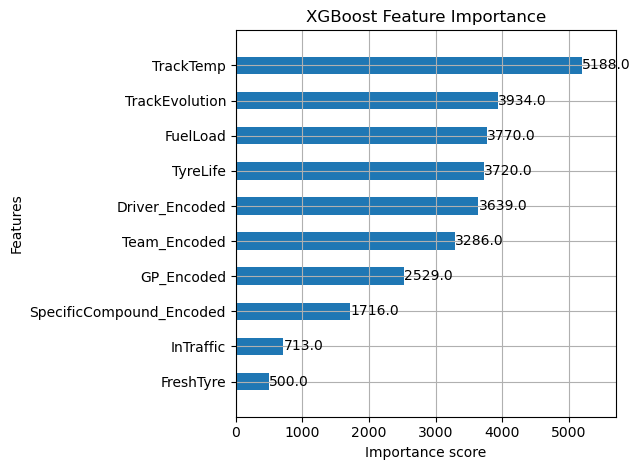

In [72]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

def train_and_evaluate_xgboost(X_train, y_train, X_test, y_test):
    """
    Trains an XGBoost Regressor to predict LapDeltaSeconds 
    and evaluates its performance on the unseen test set.
    """
    print("🚀 Starting XGBoost training...")
    
    # 1. Model Initialization
    # We use moderate hyperparameters for a solid baseline
    model = xgb.XGBRegressor(
        n_estimators=500,        # Number of decision trees
        learning_rate=0.05,      # Step size shrinkage to prevent overfitting
        max_depth=6,             # Maximum depth of a tree (complexity)
        subsample=0.8,           # Use 80% of rows per tree to generalize better
        colsample_bytree=0.8,    # Use 80% of features per tree
        random_state=42,         # For reproducibility
        n_jobs=-1                # Use all CPU cores
    )
    
    # 2. Fit the model (Training)
    model.fit(
        X_train, 
        y_train,
        eval_set=[(X_train, y_train), (X_test, y_test)],
        verbose=100  # Print progress every 100 trees
    )
    
    print("\n✅ Training complete! Evaluating on Test Set...")
    
    # 3. Predict on the Test Set (Second half of 2025)
    predictions = model.predict(X_test)
    
    # 4. Calculate Error Metrics
    # MAE is the easiest to interpret: "On average, how many seconds are we off?"
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    
    print("-" * 30)
    print(f"📊 Model Performance (Test Set):")
    print(f"Mean Absolute Error (MAE): {mae:.3f} seconds")
    print(f"Root Mean Squared Error (RMSE): {rmse:.3f} seconds")
    print("-" * 30)
    
    # 5. Plot Feature Importance
    # This shows us what the model thinks is most important (e.g., Fuel vs Tyre)
    plt.figure(figsize=(10, 6))
    xgb.plot_importance(model, importance_type='weight', max_num_features=10, height=0.5)
    plt.title("XGBoost Feature Importance")
    plt.tight_layout()
    plt.show()
    
    return model

# Execute the training
# Make sure X_train, y_train, X_test, y_test are defined from the previous step
trained_model = train_and_evaluate_xgboost(X_train, y_train, X_test, y_test)

In [ ]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error
import numpy as np

def optimize_xgboost(X_train, y_train, X_test, y_test):
    """
    Performs a Randomized Search to find the best XGBoost hyperparameters
    to reduce overfitting and improve MAE.
    """
    print("🔍 Starting Randomized Search for Hyperparameter Tuning...")
    
    # 1. Define the base model
    xgb_model = xgb.XGBRegressor(random_state=42, n_jobs=-1)
    
    # 2. Define the parameter grid to search
    # We focus on parameters that control model complexity (prevent overfitting)
    param_distributions = {
        'n_estimators': [300, 500, 800],           # Number of trees
        'learning_rate': [0.01, 0.05, 0.1],        # Step size
        'max_depth': [3, 4, 5, 6],                 # Shallower trees prevent memorization
        'min_child_weight': [1, 3, 5, 7],          # Higher values force more conservative models
        'subsample': [0.6, 0.7, 0.8, 0.9],         # Row sampling
        'colsample_bytree': [0.6, 0.7, 0.8, 0.9],  # Feature sampling
        'gamma': [0, 0.1, 0.5, 1.0]                # Minimum loss reduction required to make a split
    }
    
    # 3. Initialize RandomizedSearchCV
    # n_iter=20 means it will try 20 random combinations (increase for better results, but takes longer)
    # cv=3 means 3-fold cross-validation
    random_search = RandomizedSearchCV(
        estimator=xgb_model,
        param_distributions=param_distributions,
        n_iter=20, 
        scoring='neg_mean_absolute_error', # We want to minimize MAE
        cv=3,
        verbose=2,
        random_state=42,
        n_jobs=-1
    )
    
    # 4. Run the search (Note: this might take a few minutes)
    random_search.fit(X_train, y_train)
    
    # 5. Extract the best model
    best_model = random_search.best_estimator_
    print("\n✅ Optimization Complete!")
    print(f"🏆 Best Hyperparameters found:\n{random_search.best_params_}")
    
    # 6. Evaluate the best model on our Test Set (2025)
    best_predictions = best_model.predict(X_test)
    best_mae = mean_absolute_error(y_test, best_predictions)
    
    print("-" * 30)
    print(f"📊 Optimized Model Performance:")
    print(f"New Mean Absolute Error (MAE): {best_mae:.3f} seconds")
    print("-" * 30)
    
    return best_model, random_search.best_params_

# Execute the optimization
# WARNING: This cell will take a few minutes to run depending on your CPU!
best_xgb_model, best_params = optimize_xgboost(X_train, y_train, X_test, y_test)



🔍 Starting Randomized Search for Hyperparameter Tuning...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

✅ Optimization Complete!
🏆 Best Hyperparameters found:
{'subsample': 0.6, 'n_estimators': 800, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0.5, 'colsample_bytree': 0.6}
------------------------------
📊 Optimized Model Performance:
New Mean Absolute Error (MAE): 0.948 seconds
------------------------------


<Figure size 1000x600 with 0 Axes>

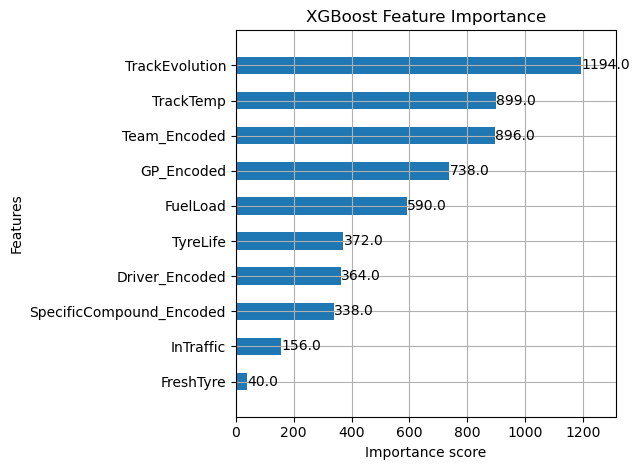

In [74]:
plt.figure(figsize=(10, 6))
xgb.plot_importance(best_xgb_model, importance_type='weight', max_num_features=10, height=0.5)
plt.title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()

In [75]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error

def micro_tune_xgboost(X_train, y_train, X_test, y_test):
    """
    Performs a strict Grid Search around the best parameters found previously
    to squeeze out the last bits of performance.
    """
    print("🔬 Starting strict GridSearchCV for micro-tuning...")
    
    # 1. Initialize model with the static best parameters we already found
    # We lock gamma, subsample, colsample_bytree, and min_child_weight
    xgb_base = xgb.XGBRegressor(
        gamma=0.5,
        subsample=0.6,
        colsample_bytree=0.6,
        min_child_weight=5,
        random_state=42,
        n_jobs=-1
    )
    
    # 2. Define the exact grid to test completely
    # Testing slightly below and slightly above our previous bests
    param_grid = {
        'n_estimators': [750, 800, 900],        # Is more trees better?
        'learning_rate': [0.008, 0.01, 0.015],  # Tweaking the learning speed
        'max_depth': [2, 3, 4]                  # Testing if even simpler (2) or slightly deeper (4) is better
    }
    
    # 3. Setup GridSearchCV
    # 3x3x3 = 27 total combinations. With cv=3, that's 81 fits.
    grid_search = GridSearchCV(
        estimator=xgb_base,
        param_grid=param_grid,
        scoring='neg_mean_absolute_error',
        cv=3,
        verbose=2,
        n_jobs=-1
    )
    
    # 4. Run the exhaustive search
    grid_search.fit(X_train, y_train)
    
    # 5. Extract and evaluate the absolute best model
    ultimate_model = grid_search.best_estimator_
    
    print("\n🏁 Grid Search Complete!")
    print(f"🏆 Ultimate Hyperparameters:\n{grid_search.best_params_}")
    
    # 6. Final Test Set Evaluation
    final_predictions = ultimate_model.predict(X_test)
    final_mae = mean_absolute_error(y_test, final_predictions)
    
    print("-" * 30)
    print(f"🚀 Final Optimized Model Performance:")
    print(f"Ultimate Mean Absolute Error (MAE): {final_mae:.3f} seconds")
    print("-" * 30)
    
    return ultimate_model

# Run the final optimization!
ultimate_xgb_model = micro_tune_xgboost(X_train, y_train, X_test, y_test)

🔬 Starting strict GridSearchCV for micro-tuning...
Fitting 3 folds for each of 27 candidates, totalling 81 fits

🏁 Grid Search Complete!
🏆 Ultimate Hyperparameters:
{'learning_rate': 0.008, 'max_depth': 3, 'n_estimators': 900}
------------------------------
🚀 Final Optimized Model Performance:
Ultimate Mean Absolute Error (MAE): 0.949 seconds
------------------------------


In [76]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error

def advanced_grid_search(X_train, y_train, X_test, y_test):
    """
    Shifts the search grid to explore the boundaries hit in the previous run:
    More trees and a slower learning rate.
    """
    print("🔬 Shifting the Grid Search window based on previous boundaries...")
    
    # Base model with static parameters (locked from our best randomized search)
    xgb_base = xgb.XGBRegressor(
        gamma=0.5,
        subsample=0.6,
        colsample_bytree=0.6,
        random_state=42,
        n_jobs=-1
    )
    
    # The new shifted grid
    param_grid = {
        'n_estimators': [900, 1000, 1200],       # Expanding upwards (More trees)
        'learning_rate': [0.005, 0.008, 0.01],   # Expanding downwards (Slower learning)
        'max_depth': [3],                        # Lock at 3 (definitely the sweet spot)
        'min_child_weight': [4, 5, 6]            # Micro-tuning regularization
    }
    
    # Setup the new GridSearchCV (3x3x1x3 = 27 combinations)
    grid_search = GridSearchCV(
        estimator=xgb_base,
        param_grid=param_grid,
        scoring='neg_mean_absolute_error',
        cv=3,
        verbose=2,
        n_jobs=-1
    )
    
    # Run the search
    grid_search.fit(X_train, y_train)
    
    best_model = grid_search.best_estimator_
    
    print("\n🏁 Advanced Grid Search Complete!")
    print(f"🏆 Best Hyperparameters:\n{grid_search.best_params_}")
    
    # Final evaluation
    final_predictions = best_model.predict(X_test)
    final_mae = mean_absolute_error(y_test, final_predictions)
    
    print("-" * 30)
    print(f"🚀 New Optimized MAE: {final_mae:.3f} seconds")
    print("-" * 30)
    
    return best_model

# Run the shifted optimization
ultimate_xgb_model = advanced_grid_search(X_train, y_train, X_test, y_test)

🔬 Shifting the Grid Search window based on previous boundaries...
Fitting 3 folds for each of 27 candidates, totalling 81 fits

🏁 Advanced Grid Search Complete!
🏆 Best Hyperparameters:
{'learning_rate': 0.008, 'max_depth': 3, 'min_child_weight': 5, 'n_estimators': 900}
------------------------------
🚀 New Optimized MAE: 0.949 seconds
------------------------------


<Figure size 1000x600 with 0 Axes>

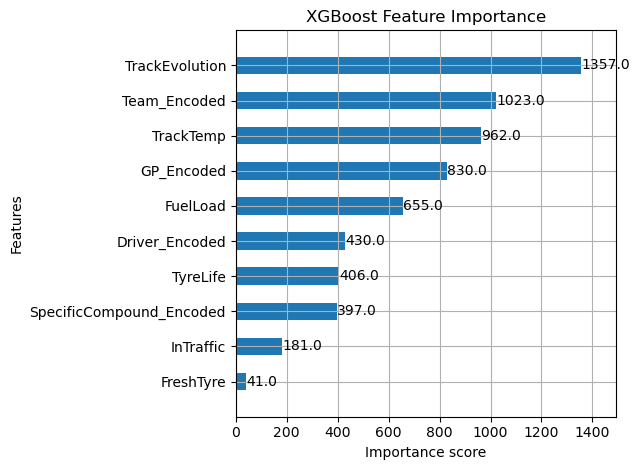

In [77]:
plt.figure(figsize=(10, 6))
xgb.plot_importance(ultimate_xgb_model, importance_type='weight', max_num_features=10, height=0.5)
plt.title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()

In [78]:
import joblib
import xgboost as xgb

# ==========================================
# 1. SAVING THE MODEL AND ENCODERS
# ==========================================
def save_model_and_encoders(model, team_enc, driver_enc, gp_enc):
    """
    Saves the trained XGBoost model and the LabelEncoders.
    """
    print("💾 Saving the model and encoders...")
    
    # Save the XGBoost model (JSON is the native and safest format for XGB)
    model.save_model('xgb_race_strategy_model.json')
    
    # Pack the encoders into a dictionary and save them using joblib
    encoders_dict = {
        'team': team_enc,
        'driver': driver_enc,
        'gp': gp_enc
    }
    joblib.dump(encoders_dict, 'label_encoders.pkl')
    
    print("✅ Model and encoders saved successfully!")

# Execute the save function (using your best model from Grid Search)
save_model_and_encoders(ultimate_xgb_model, team_encoder, driver_encoder, gp_encoder)

💾 Saving the model and encoders...
✅ Model and encoders saved successfully!


In [24]:
import joblib
import xgboost as xgb

# ==========================================
# 2. LOADING EVERYTHING BACK (For future use)
# ==========================================
def load_model_and_encoders():
    """
    Loads the XGBoost model and Encoders from disk.
    Use this when you restart your Jupyter Notebook.
    """
    print("\n🔄 Loading model and encoders from disk...")
    
    # Initialize an empty model and load the weights
    loaded_model = xgb.XGBRegressor()
    loaded_model.load_model('xgb_race_strategy_model.json')
    
    # Load the dictionary containing our label encoders
    loaded_encoders = joblib.load('label_encoders.pkl')
    
    print("✅ Load complete! Ready to simulate.")
    return loaded_model, loaded_encoders

# How to use it tomorrow:
loaded_xgb, loaded_enc = load_model_and_encoders()


🔄 Loading model and encoders from disk...
✅ Load complete! Ready to simulate.


______ 

SIMULATION

In [3]:
s1 = ff1.get_session(2024, 'monza', 'R')
s1.load(telemetry=False, weather=True)

core           INFO 	Loading data for Italian Grand Prix - Race [v3.6.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['16', '81', '4', '55', '44', '1', '63', '11', '23', '20', '14', '43', '3', '31', '10', '77', '27', '24', '18', '22']


In [28]:
import pandas as pd
import numpy as np

def get_historical_track_evolution(csv_path, gp_encoded):
    """
    Reads the full dataset and computes the average track evolution
    lap by lap for a specific circuit.
    """
    df = pd.read_csv(csv_path)
    
    df_gp = df[df['GP_Encoded'] == gp_encoded]
    
    # 
    # Create dict {LapNumber: TrackEvolution_Mean}
    track_evo_curve = df_gp.groupby('LapNumber')['TrackEvolution'].mean().to_dict()
    
    # Forward Fill for missing values
    max_lap = int(df_gp['LapNumber'].max()) if not df_gp.empty else 60
    
    # Starting value
    last_valid_evo = 1.0
    for lap in range(1, max_lap + 1):
        if lap in track_evo_curve:
            last_valid_evo = track_evo_curve[lap]
        else:
            track_evo_curve[lap] = last_valid_evo
            
    return track_evo_curve


def simulate_race_strategy(model, race_config, strategy_dict, track_evo_curve):
    """
    Simulates a full race using the XGBoost model to predict lap times.
    
    :param model: The trained XGBoost model
    :param race_config: Dictionary with static race info (GP, Driver, Team, Total Laps, TrackTemp)
    :param strategy: Dictionary defining the pit stops e.g., {1: 2, 20: 1} 
                     (Start on Compound 2, pit lap 20 for Compound 1)
    :return: Total estimated race time in seconds
    """
    total_race_time = 0.0
    simulated_laps = []
    
    current_compound = strategy_dict[1] 
    tyre_life = 1
    total_laps = race_config['total_laps']
    
    for lap in range(1, race_config['total_laps'] + 1):
        
        # 1. Check for Pit Stop
        if lap in strategy_dict and lap != 1:
            current_compound = strategy_dict[lap]
            tyre_life = 1 # Reset tyre life
            total_race_time += race_config['pit_stop_loss'] # Add pit stop penalty (e.g., 24 seconds)
            
        # 2. Calculate Fuel Load (Percentage left)
        fuel_load = 100 * (1 - (lap / race_config['total_laps']))
        
        # 3. Track Evolution: TAKEN FROM REAL DATA (with safety fallback)
        # If for any reason the lap goes beyond historical data, use the last known value
        track_evo = track_evo_curve.get(lap, track_evo_curve.get(len(track_evo_curve), 1.0))
        
        # 4. Prepare the exact features our XGBoost expects
        # Features order MUST match the training phase:
        # ['TyreLife', 'FuelLoad', 'TrackTemp', 'TrackEvolution', 'InTraffic', 
        #  'SpecificCompound_Encoded', 'Team_Encoded', 'Driver_Encoded', 'GP_Encoded', 'FreshTyre']
        
        lap_features = pd.DataFrame([{
            'TyreLife': tyre_life,
            'FuelLoad': fuel_load,
            'TrackTemp': race_config['track_temp'],
            'TrackEvolution': track_evo,
            'InTraffic': 0, # Assuming clean air for the pure strategy baseline
            'SpecificCompound_Encoded': current_compound,
            'Team_Encoded': race_config['team_encoded'],
            'Driver_Encoded': race_config['driver_encoded'],
            'GP_Encoded': race_config['gp_encoded'],
            'FreshTyre': 1 # Assuming we only fit fresh tyres for now
        }])
        
        # 5. Predict the Lap Delta
        lap_delta = model.predict(lap_features)[0]
        
        # Convert Delta to absolute time (Base lap time + Delta)
        lap_time_absolute = race_config['base_lap_time'] + lap_delta
        total_race_time += lap_time_absolute
        
        # Store for visualization
        simulated_laps.append({
            'Lap': lap,
            'Predicted_Time': lap_time_absolute,
            'Compound': current_compound,
            'TyreLife': tyre_life,
            'FuelLoad': fuel_load,
            'TrackEvolution': track_evo
        })
        
        # Update tyre age for the next lap
        tyre_life += 1
        
    return total_race_time, pd.DataFrame(simulated_laps)

In [ ]:
import pandas as pd
import numpy as np
import datetime

ultimate_xgb_model, loaded_enc  = load_model_and_encoders()


# ==========================================
# 1. SETUP THE RACE CONFIGURATION
# ==========================================
# We use the label encoders we saved earlier to get the exact numeric IDs.
# Assuming 'team_encoder', 'driver_encoder', and 'gp_encoder' are loaded in your environment.

# Replace 'Italian Grand Prix' or 'Monza' with the exact string used in your dataset
gp_name = 'Italian Grand Prix' 
# driver_name = 'LEC' # Or 'Charles Leclerc', depending on your dataset
# team_name = 'Ferrari'

driver_name = 'VER' # Or 'Charles Leclerc', depending on your dataset
team_name = 'Red Bull Racing'

race_config = {
    'gp_encoded': gp_encoder.transform([gp_name])[0],
    'driver_encoded': driver_encoder.transform([driver_name])[0],
    'team_encoded': team_encoder.transform([team_name])[0],
    
    'total_laps': 53,               
    'base_lap_time': 80.901,        # Updated with the exact 2025 track record
    'pit_stop_loss': 24.0,          
    'track_temp': 40.0              
}

# ==========================================
# 2. DEFINE THE STRATEGIES TO TEST
# ==========================================
# Remember our ordinal encoding for compounds: C1=1, C2=2, C3=3, C4=4, C5=5
# In Monza, Pirelli usually brings C3(Hard), C4(Medium), C5(Soft).

# Strategy A: 1-Stop (Medium -> Hard)
# Start on Mediums (4), pit at lap 23 for Hards (3)
strategy_1_stop = {
    1: 4,   
    23: 3   
}

# Strategy B: 2-Stop (Soft -> Medium -> Soft)
# Start on Softs (5), pit lap 15 for Mediums (4), pit lap 38 for Softs (5)
strategy_2_stop = {
    1: 5,   
    15: 4,  
    38: 5   
}

# ==========================================
# 3. EXTRACT REAL TRACK EVOLUTION & RUN
# ==========================================

print("📊 Extracting historical Track Evolution for Monza...")
# Make sure the path points to your encoded CSV
csv_path = r'./f1_data/f1_dataset_encoded_22_25.csv' 
track_evo_curve = get_historical_track_evolution(csv_path, race_config['gp_encoded'])

print("🏎️ Simulating Strategy A (1-Stop: Medium-Hard)...")
time_strat_a, df_laps_a = simulate_race_strategy(ultimate_xgb_model, race_config, strategy_1_stop, track_evo_curve)

print("🏎️ Simulating Strategy B (2-Stop: Soft-Medium-Soft)...")
time_strat_b, df_laps_b = simulate_race_strategy(ultimate_xgb_model, race_config, strategy_2_stop, track_evo_curve)

# ==========================================
# 4. COMPARE RESULTS
# ==========================================
# def format_time(total_seconds):
#     """
#     Helper function to format seconds using Python's built-in datetime library.
#     It formats the time as HH:MM:SS.000 (F1 style).
#     """
#     # Create a timedelta object which automatically handles the math
#     td = datetime.timedelta(seconds=total_seconds)
    
#     # Extract total seconds to format exactly with 3 decimal places (milliseconds)
#     # td.total_seconds() returns the exact float value
#     hours, remainder = divmod(td.total_seconds(), 3600)
#     minutes, seconds = divmod(remainder, 60)
    
#     # :02d ensures 2 digits for hours and minutes (e.g., 01 instead of 1)
#     # :06.3f ensures 2 digits for seconds and exactly 3 for milliseconds (e.g., 05.250)
#     return f"{int(hours):02d}:{int(minutes):02d}:{seconds:06.3f}"

# ==========================================
# 4. COMPARE RESULTS
# ==========================================
def format_time(seconds):
    """
        Helper function to format seconds into HH:MM:SS.000
    """
    hours = int(seconds // 3600)
    minutes = int((seconds % 3600) // 60)
    secs = seconds % 60
    return f"{hours:02d}h {minutes:02d}m {secs:.3f}s" 


print("\n" + "="*40)
print("🏁 RACE SIMULATION RESULTS - MONZA")
print("="*40)
print(f"Strategy A (1-Stop): {format_time(time_strat_a)}")
print(f"Strategy B (2-Stop): {format_time(time_strat_b)}")

time_diff = abs(time_strat_a - time_strat_b)
if time_strat_a < time_strat_b:
    print(f"\n🏆 Strategy A wins by {time_diff:.3f} seconds!")
else:
    print(f"\n🏆 Strategy B wins by {time_diff:.3f} seconds!")
print("="*40)


🔄 Loading model and encoders from disk...
✅ Load complete! Ready to simulate.
📊 Extracting historical Track Evolution for Monza...
🏎️ Simulating Strategy A (1-Stop: Medium-Hard)...
🏎️ Simulating Strategy B (2-Stop: Soft-Medium-Soft)...

🏁 RACE SIMULATION RESULTS - MONZA
Strategy A (1-Stop): 01h 13m 58.657s
Strategy B (2-Stop): 01h 14m 17.109s

🏆 Strategy A wins by 18.452 seconds!


In [42]:
import pandas as pd

# ==========================================
# 5. THE STRATEGY OPTIMIZER
# ==========================================
def optimize_1_stop_strategy(model, race_config, track_evo_curve, start_compound, pit_compound, pit_window):
    """
    Brute-forces a 1-stop strategy by testing every possible pit stop lap 
    within a logical 'pit window'.
    
    :param model: The trained XGBoost model
    :param race_config: The dictionary with race info
    :param track_evo_curve: The historical track evolution dictionary
    :param start_compound: Encoded ID for the starting tire (e.g., 4 for Medium)
    :param pit_compound: Encoded ID for the second tire (e.g., 3 for Hard)
    :param pit_window: Tuple with (start_lap, end_lap) for the search space
    :return: DataFrame with all results, and the absolute best strategy dictionary
    """
    
    print(f"🔍 Optimizing 1-Stop ({start_compound} -> {pit_compound}) inside Pit Window: Laps {pit_window[0]} to {pit_window[1]}...")
    
    results = []
    best_time = float('inf')
    best_strategy = None
    best_lap = -1
    
    # Loop through every lap in the designated pit window
    for pit_lap in range(pit_window[0], pit_window[1] + 1):
        
        # 1. Generate the strategy dictionary for this specific lap
        current_strategy = {
            1: start_compound,
            pit_lap: pit_compound
        }
        
        # 2. Simulate the race with this strategy
        total_time, _ = simulate_race_strategy(model, race_config, current_strategy, track_evo_curve)
        
        # 3. Store the result
        results.append({
            'Pit_Lap': pit_lap,
            'Total_Race_Time_Sec': total_time,
            'Formatted_Time': format_time(total_time)
        })
        
        # 4. Check if this is the fastest one we've seen so far
        if total_time < best_time:
            best_time = total_time
            best_strategy = current_strategy
            best_lap = pit_lap
            
    # Convert results to a nice DataFrame for analysis
    df_results = pd.DataFrame(results)
    
    print("\n✅ Optimization Complete!")
    print(f"🏆 BEST PIT LAP: Lap {best_lap}")
    print(f"⏱️ BEST TOTAL TIME: {format_time(best_time)}")
    
    return df_results, best_strategy


# ==========================================
# 6. RUN THE OPTIMIZER FOR MONZA
# ==========================================
# Let's test a Medium (4) to Hard (3) strategy.
# A realistic pit window for this in a 53-lap race is between lap 18 and lap 32.

start_tyre = 4 # Medium
pit_tyre = 3   # Hard
window = (18, 40)

df_optimization_results, ultimate_strategy = optimize_1_stop_strategy(
    model=ultimate_xgb_model, 
    race_config=race_config, 
    track_evo_curve=track_evo_curve, 
    start_compound=start_tyre, 
    pit_compound=pit_tyre, 
    pit_window=window
)

# Display the top 5 fastest pit laps
print("\nTop 5 Fastest Pit Stop Laps:")
print(df_optimization_results.sort_values(by='Total_Race_Time_Sec').head())

🔍 Optimizing 1-Stop (4 -> 3) inside Pit Window: Laps 18 to 40...

✅ Optimization Complete!
🏆 BEST PIT LAP: Lap 37
⏱️ BEST TOTAL TIME: 01h 13m 55.725s

Top 5 Fastest Pit Stop Laps:
    Pit_Lap  Total_Race_Time_Sec   Formatted_Time
19       37          4435.725098  01h 13m 55.725s
20       38          4435.765137  01h 13m 55.765s
18       36          4435.804688  01h 13m 55.805s
21       39          4435.877930  01h 13m 55.878s
17       35          4435.908203  01h 13m 55.908s


In [44]:
# ==========================================
# SETUP FOR IMOLA (EMILIA ROMAGNA GP)
# ==========================================

gp_name = 'Emilia Romagna Grand Prix' 
driver_name = 'VER' 
team_name = 'Red Bull Racing'

# 1. Update Race Configuration for Imola
race_config = {
    'gp_encoded': gp_encoder.transform([gp_name])[0],
    'driver_encoded': driver_encoder.transform([driver_name])[0],
    'team_encoded': team_encoder.transform([team_name])[0],
    
    'total_laps': 63,               # Imola is 63 laps long
    'base_lap_time': 77.988,        # Realistic fastest race lap (1:17:998)
    'pit_stop_loss': 28.5,          # Imola pit lane is longer than Monza
    'track_temp': 38.0              # Typical Imola track temperature
}

# 2. Extract Imola's Track Evolution
print(f"📊 Extracting historical Track Evolution for {gp_name}...")
csv_path = r'.\f1_data\f1_dataset_encoded_22_25.csv' 
track_evo_curve = get_historical_track_evolution(csv_path, race_config['gp_encoded'])

# 3. Define Imola Pit Window (Wider window due to 63 laps)
# A 1-stop strategy (Medium -> Hard) usually pits between lap 20 and 45 here.
start_tyre = 4 # Medium
pit_tyre = 3   # Hard
imola_window = (20, 55)

# 4. Run the Optimizer!
df_optimization_results, ultimate_strategy = optimize_1_stop_strategy(
    model=ultimate_xgb_model, 
    race_config=race_config, 
    track_evo_curve=track_evo_curve, 
    start_compound=start_tyre, 
    pit_compound=pit_tyre, 
    pit_window=imola_window
)

print("\nTop 5 Fastest Pit Stop Laps for Imola:")
print(df_optimization_results.sort_values(by='Total_Race_Time_Sec').head())

📊 Extracting historical Track Evolution for Emilia Romagna Grand Prix...
🔍 Optimizing 1-Stop (4 -> 3) inside Pit Window: Laps 20 to 55...

✅ Optimization Complete!
🏆 BEST PIT LAP: Lap 46
⏱️ BEST TOTAL TIME: 01h 25m 12.409s

Top 5 Fastest Pit Stop Laps for Imola:
    Pit_Lap  Total_Race_Time_Sec   Formatted_Time
26       46          5112.408691  01h 25m 12.409s
25       45          5112.437988  01h 25m 12.438s
27       47          5112.446289  01h 25m 12.446s
28       48          5112.478027  01h 25m 12.478s
24       44          5112.482422  01h 25m 12.482s


In [45]:
import pandas as pd
from tqdm import tqdm # Optional: helps to show a progress bar! (pip install tqdm)

# ==========================================
# 8. THE UNIVERSAL STRATEGY OPTIMIZER
# ==========================================

def generate_valid_strategies(total_laps, tire_limits, min_stint=8):
    """
    Generates all physically and legally possible 1-stop and 2-stop strategies.
    
    :param total_laps: Total laps of the race (e.g., 63 for Imola)
    :param tire_limits: Dictionary with max laps per compound {5: 22, 4: 40, 3: 55}
    :param min_stint: Minimum laps between pit stops to avoid absurd strategies
    :return: A list of strategy dictionaries
    """
    valid_strategies = []
    compounds = list(tire_limits.keys()) # e.g., [3, 4, 5] for Hard, Medium, Soft
    
    # --- 1-STOP STRATEGIES ---
    for start_c in compounds:
        for stint2_c in compounds:
            # FIA Rule: Must use at least two different compounds
            if start_c == stint2_c: continue
                
            for pit1 in range(min_stint, total_laps - min_stint + 1):
                stint1_laps = pit1 - 1
                stint2_laps = total_laps - pit1 + 1
                
                # Check Physical Constraints (Tire Life)
                if stint1_laps <= tire_limits[start_c] and stint2_laps <= tire_limits[stint2_c]:
                    valid_strategies.append({
                        'type': '1-Stop',
                        'dict': {1: start_c, pit1: stint2_c},
                        'name': f"1-Stop: C{start_c} -> C{stint2_c} (Pit Lap {pit1})"
                    })

    # --- 2-STOP STRATEGIES ---
    for start_c in compounds:
        for stint2_c in compounds:
            for stint3_c in compounds:
                # FIA Rule: Must use at least two DIFFERENT compounds overall
                if start_c == stint2_c and stint2_c == stint3_c: continue
                    
                for pit1 in range(min_stint, total_laps - (min_stint * 2) + 1):
                    for pit2 in range(pit1 + min_stint, total_laps - min_stint + 1):
                        stint1_laps = pit1 - 1
                        stint2_laps = pit2 - pit1
                        stint3_laps = total_laps - pit2 + 1
                        
                        # Check Physical Constraints (Tire Life)
                        if (stint1_laps <= tire_limits[start_c] and 
                            stint2_laps <= tire_limits[stint2_c] and 
                            stint3_laps <= tire_limits[stint3_c]):
                            
                            valid_strategies.append({
                                'type': '2-Stop',
                                'dict': {1: start_c, pit1: stint2_c, pit2: stint3_c},
                                'name': f"2-Stop: C{start_c} -> C{stint2_c} -> C{stint3_c} (Pits {pit1}, {pit2})"
                            })
                            
    return valid_strategies


# ==========================================
# 9. EXECUTE THE MASTER SIMULATION
# ==========================================

# 1. Define Tire Physics Limits (Adjust these based on track severity)
# Assuming 5=Soft, 4=Medium, 3=Hard
imola_tire_limits = {
    5: 22,  # Softs melt after ~22 laps
    4: 40,  # Mediums last ~40 laps
    3: 58   # Hards are rocks, can last almost the whole race
}

# 2. Generate all legal strategies
print(f"⚙️ Generating combinatorial space for Imola ({race_config['total_laps']} laps)...")
all_strategies = generate_valid_strategies(race_config['total_laps'], imola_tire_limits)
print(f"✅ Found {len(all_strategies)} physically possible strategies to simulate.")

# 3. Evaluate every single strategy
print("🚀 Simulating all strategies (This might take a few seconds)...")
master_results = []

# Using tqdm to show a nice progress bar if you have it installed
for strat in all_strategies: # If you have tqdm, use: for strat in tqdm(all_strategies):
    total_time, _ = simulate_race_strategy(
        model=ultimate_xgb_model, 
        race_config=race_config, 
        strategy_dict=strat['dict'], 
        track_evo_curve=track_evo_curve
    )
    
    master_results.append({
        'Strategy_Type': strat['type'],
        'Description': strat['name'],
        'Total_Time_Sec': total_time,
        'Formatted_Time': format_time(total_time)
    })

# 4. Sort and Display the Ultimate Top 10
df_master = pd.DataFrame(master_results)
df_master = df_master.sort_values(by='Total_Time_Sec').reset_index(drop=True)

print("\n" + "="*70)
print("🏆 THE ULTIMATE STRATEGY RANKING - IMOLA (MAX VERSTAPPEN)")
print("="*70)

# Print the top 10 best strategies
pd.set_option('display.max_colwidth', None) # Ensures the description doesn't get cut off
print(df_master[['Strategy_Type', 'Description', 'Formatted_Time']].head(10))

print("\n🚨 WORST STRATEGY (For reference):")
print(df_master[['Strategy_Type', 'Description', 'Formatted_Time']].tail(1))

⚙️ Generating combinatorial space for Imola (63 laps)...
✅ Found 11620 physically possible strategies to simulate.
🚀 Simulating all strategies (This might take a few seconds)...

🏆 THE ULTIMATE STRATEGY RANKING - IMOLA (MAX VERSTAPPEN)
  Strategy_Type                    Description   Formatted_Time
0        1-Stop  1-Stop: C4 -> C3 (Pit Lap 41)  01h 25m 12.974s
1        1-Stop  1-Stop: C4 -> C3 (Pit Lap 40)  01h 25m 13.189s
2        1-Stop  1-Stop: C4 -> C3 (Pit Lap 39)  01h 25m 13.411s
3        1-Stop  1-Stop: C4 -> C3 (Pit Lap 38)  01h 25m 13.661s
4        1-Stop  1-Stop: C4 -> C3 (Pit Lap 37)  01h 25m 13.911s
5        1-Stop  1-Stop: C4 -> C3 (Pit Lap 36)  01h 25m 14.179s
6        1-Stop  1-Stop: C4 -> C3 (Pit Lap 35)  01h 25m 14.444s
7        1-Stop  1-Stop: C4 -> C3 (Pit Lap 34)  01h 25m 14.696s
8        1-Stop  1-Stop: C4 -> C3 (Pit Lap 33)  01h 25m 14.945s
9        1-Stop  1-Stop: C4 -> C3 (Pit Lap 32)  01h 25m 15.189s

🚨 WORST STRATEGY (For reference):
      Strategy_Type      

In [49]:
data_dir = './f1_data'
os.makedirs(data_dir, exist_ok=True)

output_file = os.path.join(data_dir, 'f1_prediction_imola_max.csv')
df_master.to_csv(output_file, index=False)
print(f"\n✅ Dataset saved to {df_master} | Total rows: {len(df_master)}")


✅ Dataset saved to       Strategy_Type                          Description  Total_Time_Sec  \
0            1-Stop        1-Stop: C4 -> C3 (Pit Lap 41)     5112.974121   
1            1-Stop        1-Stop: C4 -> C3 (Pit Lap 40)     5113.189453   
2            1-Stop        1-Stop: C4 -> C3 (Pit Lap 39)     5113.411133   
3            1-Stop        1-Stop: C4 -> C3 (Pit Lap 38)     5113.661133   
4            1-Stop        1-Stop: C4 -> C3 (Pit Lap 37)     5113.911133   
...             ...                                  ...             ...   
11615        2-Stop  2-Stop: C3 -> C5 -> C3 (Pits 9, 17)     5148.802734   
11616        2-Stop  2-Stop: C5 -> C3 -> C3 (Pits 8, 16)     5148.968750   
11617        2-Stop  2-Stop: C4 -> C3 -> C3 (Pits 8, 16)     5148.968750   
11618        2-Stop  2-Stop: C3 -> C5 -> C3 (Pits 8, 16)     5149.071289   
11619        2-Stop  2-Stop: C3 -> C4 -> C3 (Pits 8, 16)     5149.071289   

        Formatted_Time  
0      01h 25m 12.974s  
1      01h 25m 13

In [48]:
df_master[df_master['Description'] == '2-Stop: C4 -> C3 -> C3 (Pits 29, 46)']

,Strategy_Type,Description,Total_Time_Sec,Formatted_Time
1648,2-Stop,"2-Stop: C4 -> C3 -> C3 (Pits 29, 46)",5138.094727,01h 25m 38.095s


In [51]:
df_master[df_master['Description'] == '1-Stop: C4 -> C3 (Pit Lap 24)']

,Strategy_Type,Description,Total_Time_Sec,Formatted_Time
17,1-Stop,1-Stop: C4 -> C3 (Pit Lap 24),5117.610352,01h 25m 17.610s


In [50]:
df_master

,Strategy_Type,Description,Total_Time_Sec,Formatted_Time
0,1-Stop,1-Stop: C4 -> C3 (Pit Lap 41),5112.974121,01h 25m 12.974s
1,1-Stop,1-Stop: C4 -> C3 (Pit Lap 40),5113.189453,01h 25m 13.189s
2,1-Stop,1-Stop: C4 -> C3 (Pit Lap 39),5113.411133,01h 25m 13.411s
3,1-Stop,1-Stop: C4 -> C3 (Pit Lap 38),5113.661133,01h 25m 13.661s
4,1-Stop,1-Stop: C4 -> C3 (Pit Lap 37),5113.911133,01h 25m 13.911s
...,...,...,...,...
11615,2-Stop,"2-Stop: C3 -> C5 -> C3 (Pits 9, 17)",5148.802734,01h 25m 48.803s
11616,2-Stop,"2-Stop: C5 -> C3 -> C3 (Pits 8, 16)",5148.968750,01h 25m 48.969s
11617,2-Stop,"2-Stop: C4 -> C3 -> C3 (Pits 8, 16)",5148.968750,01h 25m 48.969s
11618,2-Stop,"2-Stop: C3 -> C5 -> C3 (Pits 8, 16)",5149.071289,01h 25m 49.071s


In [53]:
import pandas as pd

# ==========================================
# 10. SNIPER BLIND TEST: MEXICO CITY GP 2025 (NORRIS)
# ==========================================

gp_name = 'Mexico City Grand Prix' 
driver_name = 'NOR' # Or 'Lando Norris'
team_name = 'McLaren'

# 1. Update Race Configuration for Mexico
race_config = {
    'gp_encoded': gp_encoder.transform([gp_name])[0],
    'driver_encoded': driver_encoder.transform([driver_name])[0],
    'team_encoded': team_encoder.transform([team_name])[0],
    
    'total_laps': 71,               
    'base_lap_time': 80.052,        # Fastest lap by Russell (1:20.052)
    'pit_stop_loss': 23.0,          # Average pit lane loss in Mexico
    'track_temp': 45.0              # Typical high track temp
}

# 2. Extract Mexico's Track Evolution
print(f"📊 Extracting historical Track Evolution for {gp_name}...")
csv_path = r'.\f1_data\f1_dataset_encoded_22_25.csv' 
track_evo_curve = get_historical_track_evolution(csv_path, race_config['gp_encoded'])

# 3. FAST OPTIMIZATION: Only 1-Stop (Medium -> Hard), Laps 25 to 40
print("🚀 Running Sniper Search (Medium -> Hard) around Lap 31...")
start_tyre = 4 # Medium
pit_tyre = 3   # Hard
sniper_window = (25, 40)

df_mexico, best_strat = optimize_1_stop_strategy(
    model=ultimate_xgb_model, 
    race_config=race_config, 
    track_evo_curve=track_evo_curve, 
    start_compound=start_tyre, 
    pit_compound=pit_tyre, 
    pit_window=sniper_window
)

# 4. Sort and Display Results
df_mexico = df_mexico.sort_values(by='Total_Race_Time_Sec').reset_index(drop=True)

print("\n" + "="*70)
print("🏆 TOP 5 PREDICTED PIT LAPS - MEXICO 2025")
print("="*70)
print(df_mexico[['Pit_Lap', 'Total_Race_Time_Sec', 'Formatted_Time']].head())

# 5. Math Comparison with Reality
real_time_sec = (1 * 3600) + (37 * 60) + 58.574
best_simulated_time = df_mexico.loc[0, 'Total_Race_Time_Sec']
diff = abs(real_time_sec - best_simulated_time)

print("\n" + "-"*50)
print(f"⏱️ REAL RACE TIME: 01h 37m 58.574s (Pit Lap ~31)")
print(f"⏱️ SIMULATED TIME: {df_mexico.loc[0, 'Formatted_Time']} (Best Pit Lap {df_mexico.loc[0, 'Pit_Lap']})")
print(f"⚖️ DIFFERENCE: {diff:.3f} seconds ({(diff/71):.3f}s per lap)")
print("-"*50)

📊 Extracting historical Track Evolution for Mexico City Grand Prix...
🚀 Running Sniper Search (Medium -> Hard) around Lap 31...
🔍 Optimizing 1-Stop (4 -> 3) inside Pit Window: Laps 25 to 40...

✅ Optimization Complete!
🏆 BEST PIT LAP: Lap 40
⏱️ BEST TOTAL TIME: 01h 38m 51.489s

🏆 TOP 5 PREDICTED PIT LAPS - MEXICO 2025
   Pit_Lap  Total_Race_Time_Sec   Formatted_Time
0       40          5931.489258  01h 38m 51.489s
1       39          5931.732422  01h 38m 51.732s
2       38          5931.971191  01h 38m 51.971s
3       37          5932.196289  01h 38m 52.196s
4       36          5932.399902  01h 38m 52.400s

--------------------------------------------------
⏱️ REAL RACE TIME: 01h 37m 58.574s (Pit Lap ~31)
⏱️ SIMULATED TIME: 01h 38m 51.489s (Best Pit Lap 40)
⚖️ DIFFERENCE: 52.915 seconds (0.745s per lap)
--------------------------------------------------


Arrivati a questo punto, il "motore" sotto il cofano è completo e collaudato. Hai tre strade davanti a te:

    La Frontiera Visiva (UI/Dashboard): Creare una piccola interfaccia grafica (magari con la libreria Python Streamlit) dove puoi inserire i parametri con dei menu a tendina e vedere i grafici generarsi da soli, senza toccare il codice.

    La Frontiera Multi-Agente: Evolvere il simulatore per far correre due piloti contemporaneamente e calcolare l'Undercut (es. "Se Norris si ferma al giro 22, Verstappen deve fermarsi al 23 per non perdere la posizione?").

    Fermarsi e Godersi il Lavoro: Impacchettare il codice in script puliti, scriverci un bel README e metterlo nel tuo portfolio o su GitHub, perché è un progetto di Data Science di altissimo livello.